<a href="https://colab.research.google.com/github/deva252/PYTHON-CASE-STUDY/blob/main/Copy_of_Supervised_learning_on_Breast_cancer_dataset_devapriya_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Dataset - Supervised Learning

## Objective
To build and evaluate supervised machine learning models
using the Breast Cancer dataset available in Scikit-learn.

### Topics Covered
- Data loading and understanding
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Train-test split
- Feature scaling
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- Model evaluation
- Feature importance / feature reduction
- PCA (Dimensionality Reduction)
- DBSCAN clustering
- Model comparison

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

In [ ]:
data = load_breast_cancer()

print(data)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [ ]:
print("Dataset shape:", data.data.shape)
print("Number of features:", len(data.feature_names))
print("Number of samples:", len(data.target))

Dataset shape: (569, 30)
Number of features: 30
Number of samples: 569


In [ ]:
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [ ]:
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [ ]:
df.shape

(569, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

Categorical Columns:
[]


In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]

    print(column, ":", len(outliers), "outliers")

mean radius : 14 outliers
mean texture : 7 outliers
mean perimeter : 13 outliers
mean area : 25 outliers
mean smoothness : 6 outliers
mean compactness : 16 outliers
mean concavity : 18 outliers
mean concave points : 10 outliers
mean symmetry : 15 outliers
mean fractal dimension : 15 outliers
radius error : 38 outliers
texture error : 20 outliers
perimeter error : 38 outliers
area error : 65 outliers
smoothness error : 30 outliers
compactness error : 28 outliers
concavity error : 22 outliers
concave points error : 19 outliers
symmetry error : 27 outliers
fractal dimension error : 28 outliers
worst radius : 17 outliers
worst texture : 5 outliers
worst perimeter : 15 outliers
worst area : 35 outliers
worst smoothness : 7 outliers
worst compactness : 16 outliers
worst concavity : 12 outliers
worst concave points : 0 outliers
worst symmetry : 23 outliers
worst fractal dimension : 24 outliers
target : 0 outliers


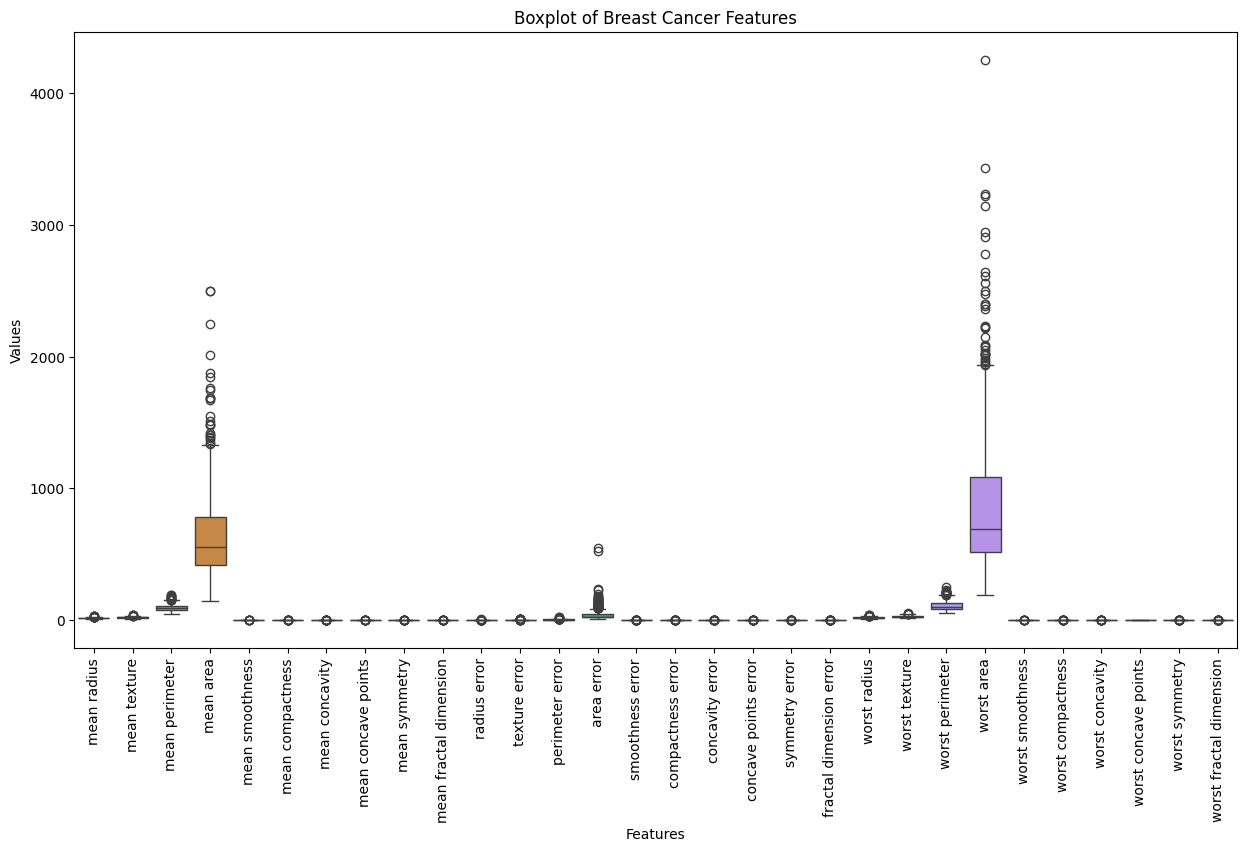

In [ ]:
X = df.drop("target", axis=1)

plt.figure(figsize=(15, 8))

sns.boxplot(data=X)

plt.xticks(rotation=90)
plt.title("Boxplot of Breast Cancer Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

In [ ]:
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]

    print(column, ":", len(outliers), "outliers")

mean radius : 14 outliers
mean texture : 7 outliers
mean perimeter : 13 outliers
mean area : 25 outliers
mean smoothness : 6 outliers
mean compactness : 16 outliers
mean concavity : 18 outliers
mean concave points : 10 outliers
mean symmetry : 15 outliers
mean fractal dimension : 15 outliers
radius error : 38 outliers
texture error : 20 outliers
perimeter error : 38 outliers
area error : 65 outliers
smoothness error : 30 outliers
compactness error : 28 outliers
concavity error : 22 outliers
concave points error : 19 outliers
symmetry error : 27 outliers
fractal dimension error : 28 outliers
worst radius : 17 outliers
worst texture : 5 outliers
worst perimeter : 15 outliers
worst area : 35 outliers
worst smoothness : 7 outliers
worst compactness : 16 outliers
worst concavity : 12 outliers
worst concave points : 0 outliers
worst symmetry : 23 outliers
worst fractal dimension : 24 outliers
target : 0 outliers


In [ ]:
print(data.target_names)

['malignant' 'benign']


In [ ]:
df["target"].value_counts()

,count
target,
1,357
0,212


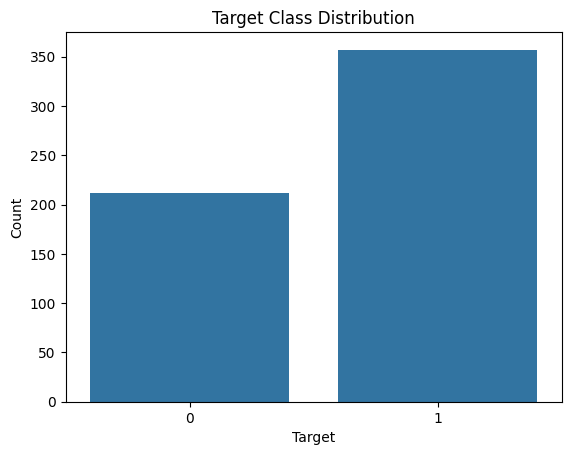

In [ ]:
sns.countplot(x="target", data=df)

plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

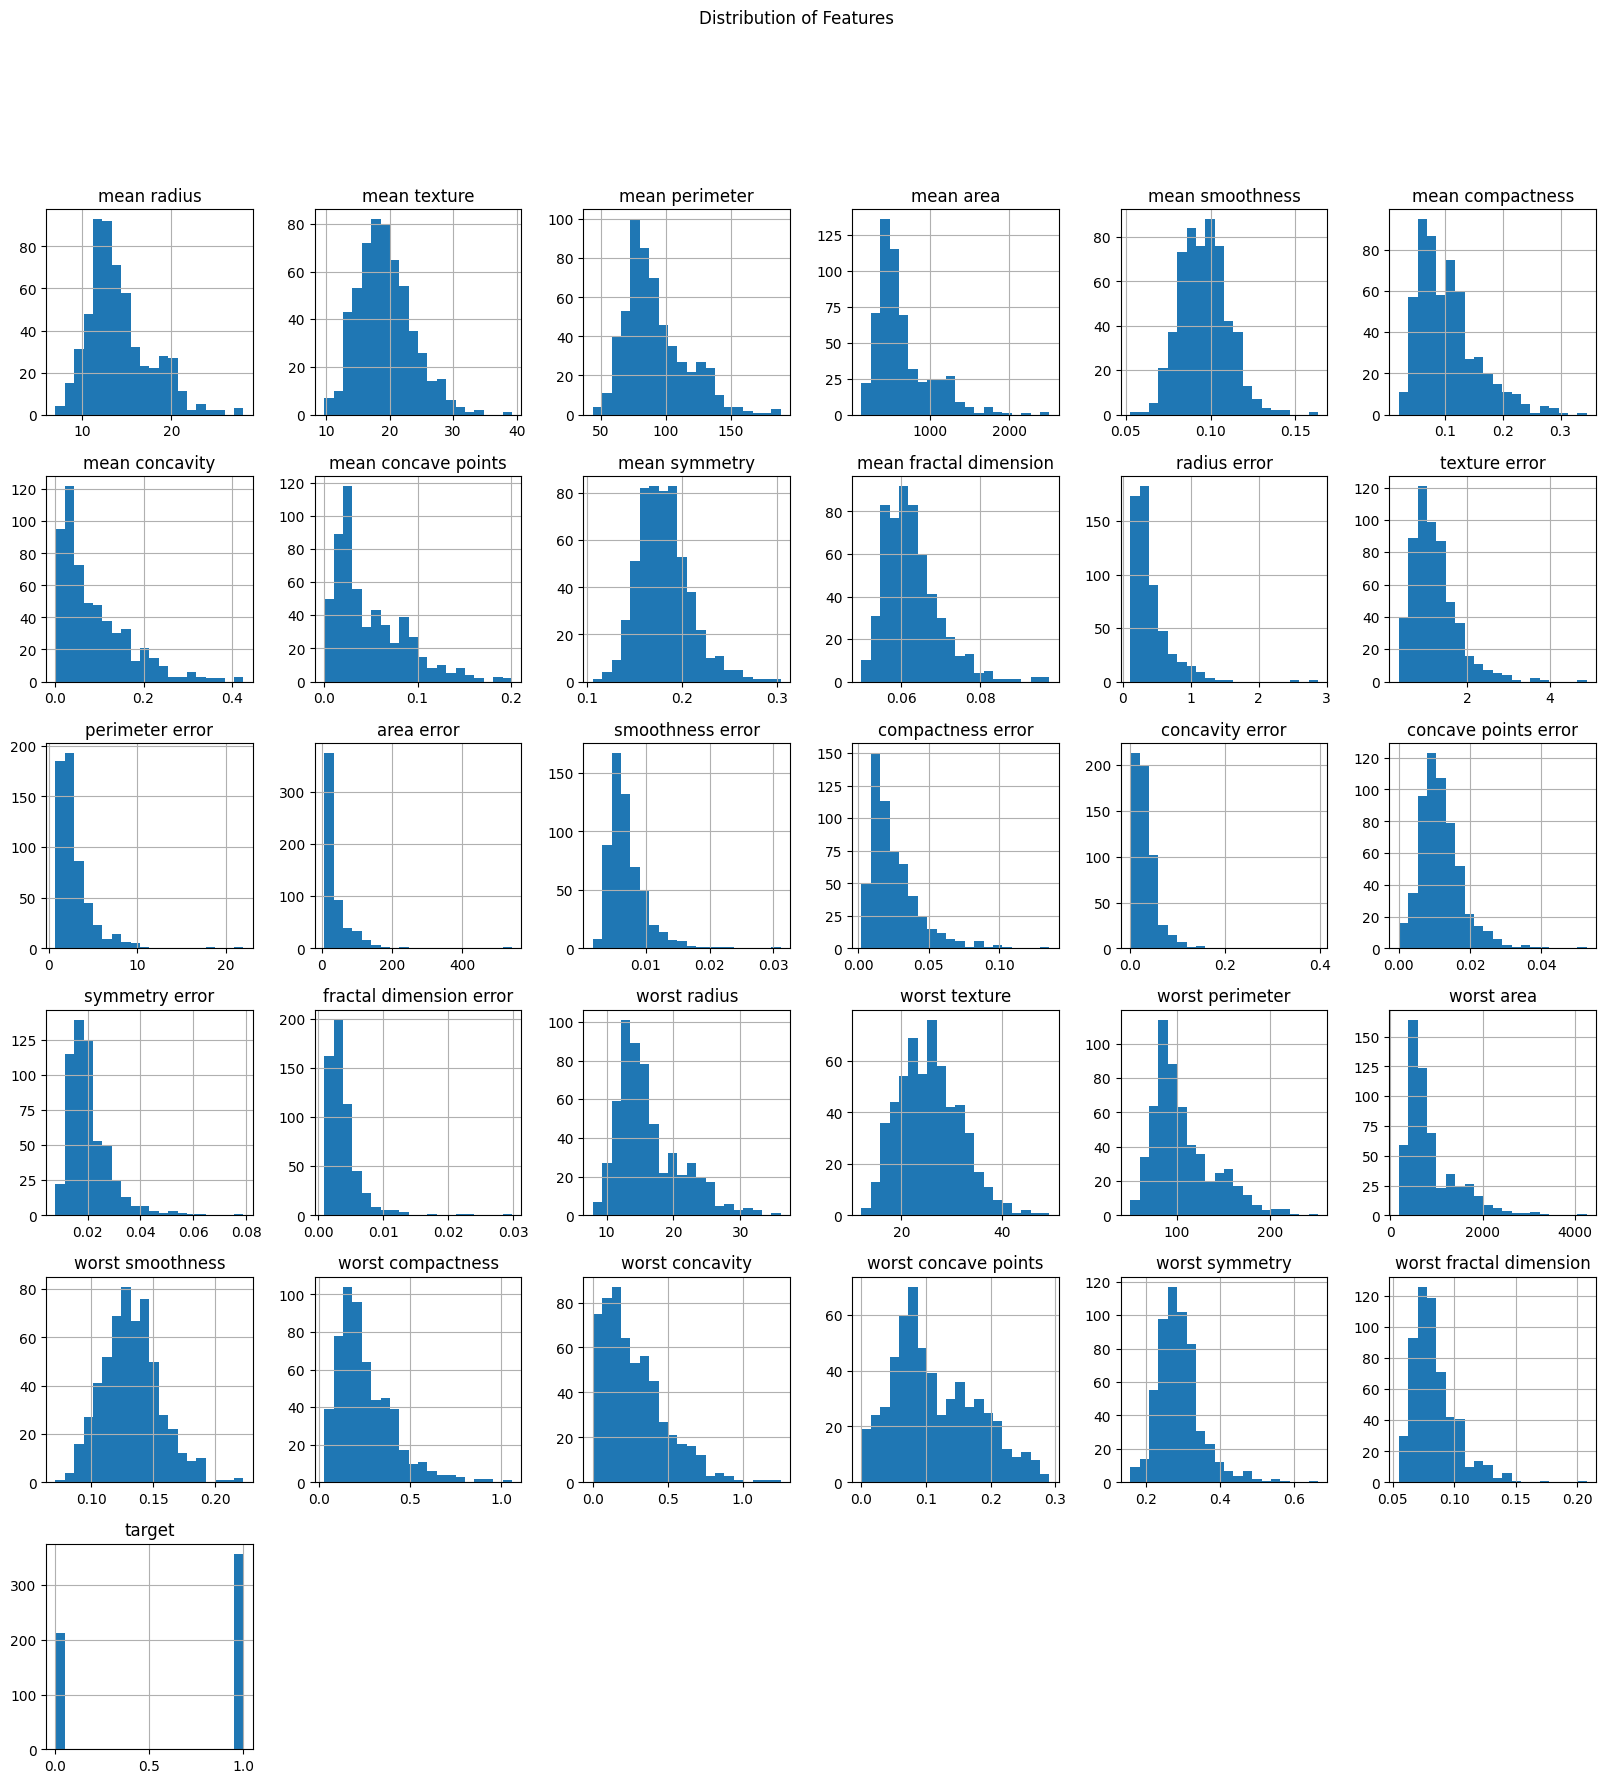

In [ ]:
df.hist(figsize=(20, 20), bins=20)

plt.suptitle("Distribution of Features")
plt.show()

In [ ]:
correlation = df.corr()

correlation.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560


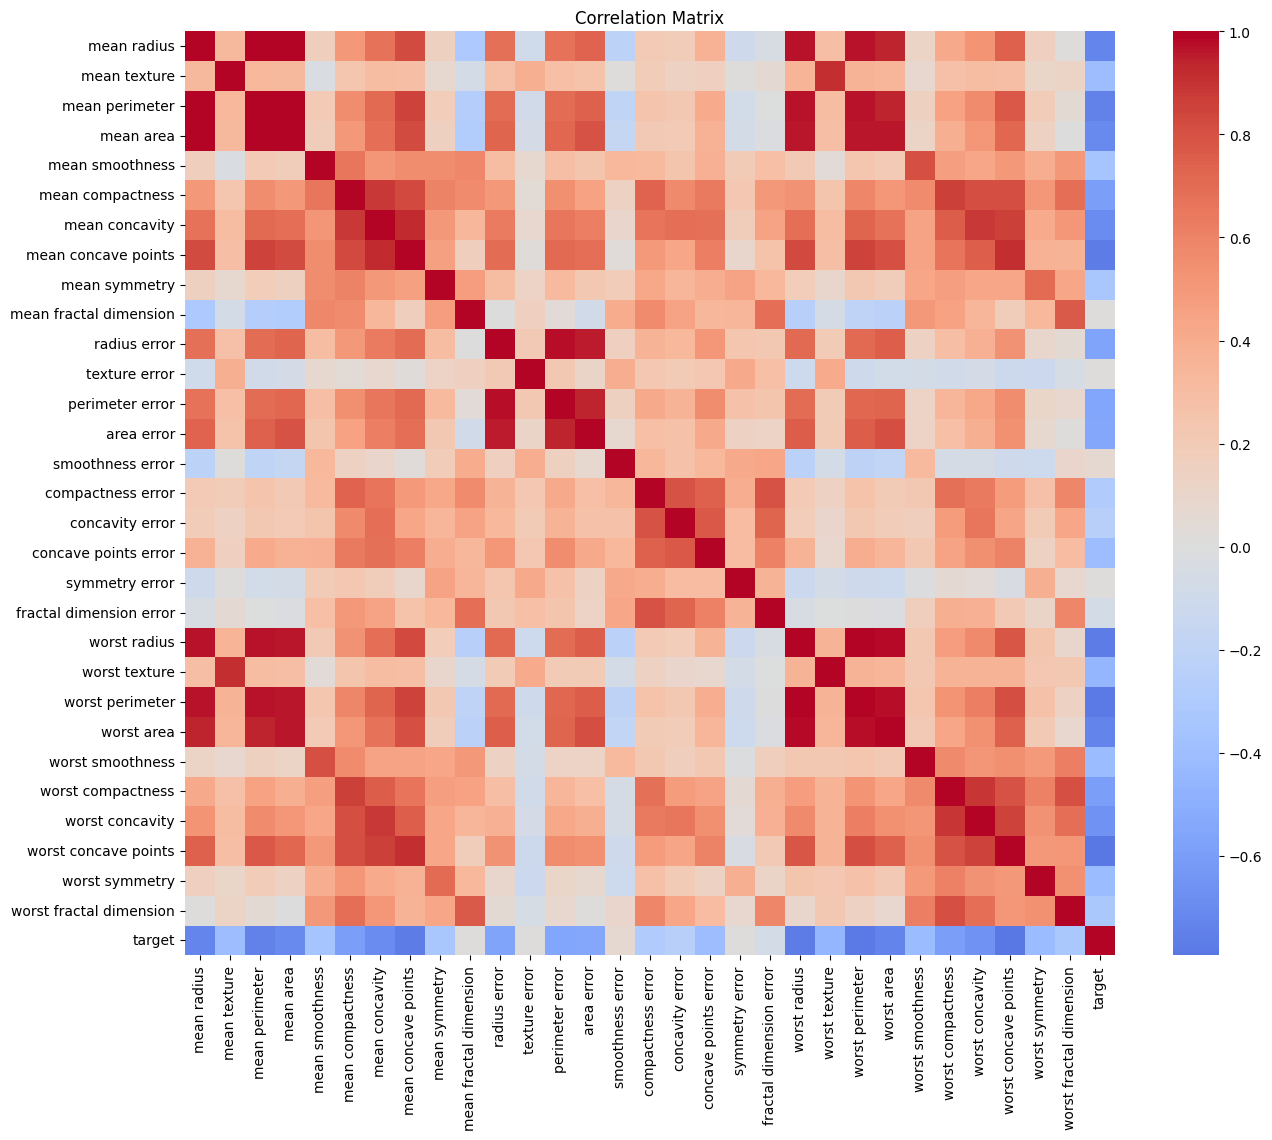

In [ ]:
plt.figure(figsize=(15, 12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
target_corr = df.corr()["target"].sort_values()

target_corr

,target
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360
worst concavity,-0.659610


In [ ]:
X = df.drop("target", axis=1)

y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=5000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression completed.")

Logistic Regression completed.


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:",
      accuracy_logistic)

Logistic Regression Accuracy: 0.9824561403508771


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN completed.")

KNN completed.


In [ ]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.956140350877193


In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree completed.")

Decision Tree completed.


In [ ]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 0.9122807017543859


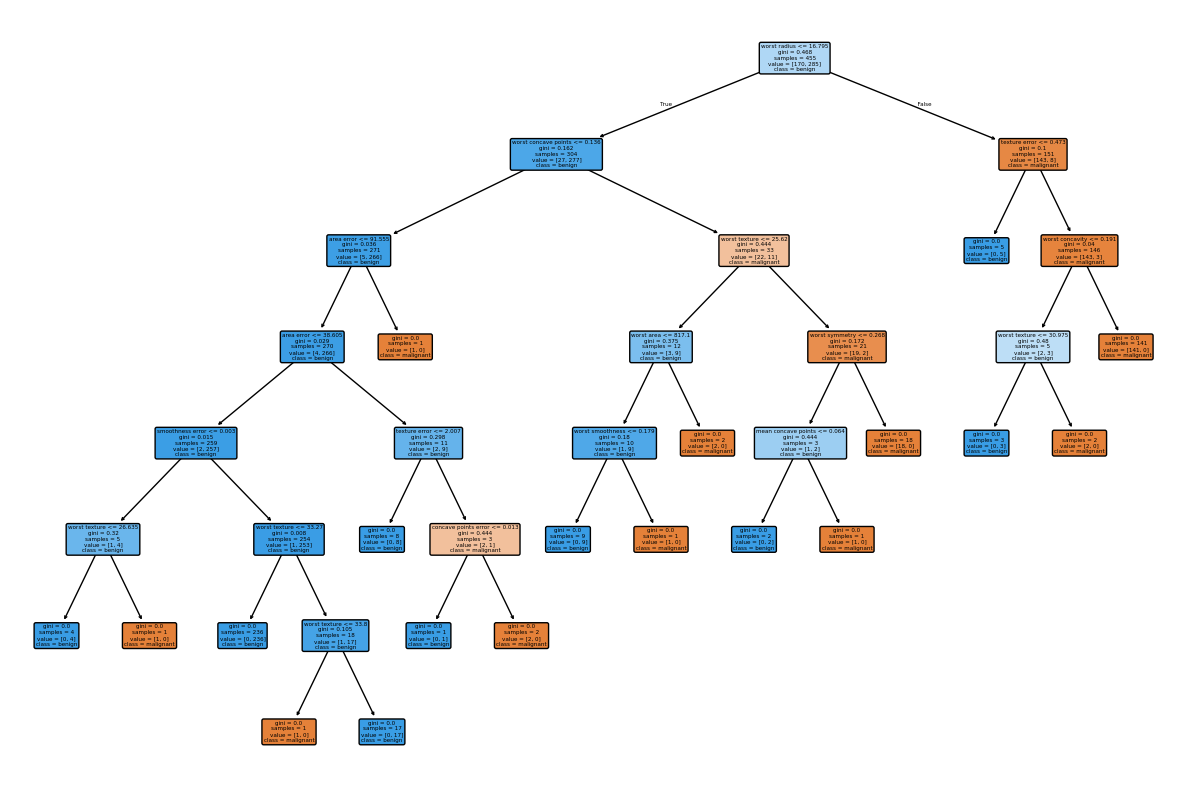

In [ ]:
from sklearn.tree import plot_tree

feature_names = X_train.columns.tolist()
class_names = data.target_names.tolist()

plt.figure(figsize=(15,10))
plot_tree(tree_model,feature_names=feature_names,class_names=class_names,filled=True,rounded=True);
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)

print("Random Forest completed.")

Random Forest completed.


In [ ]:
accuracy_forest = accuracy_score(y_test, y_pred_forest)

print("Random Forest Accuracy:", accuracy_forest)

Random Forest Accuracy: 0.956140350877193


In [ ]:
from sklearn.svm import SVC
svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM completed.")

SVM completed.


In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.9824561403508771


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_model(y_true, y_pred, model_name):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("Model:", model_name)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("-" * 40)

In [ ]:
evaluate_model(
    y_test,
    y_pred_logistic,
    "Logistic Regression"
)

Model: Logistic Regression
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861
----------------------------------------


In [ ]:
evaluate_model(
    y_test,
    y_pred_knn,
    "KNN"
)

Model: KNN
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655
----------------------------------------


In [ ]:
evaluate_model(
    y_test,
    y_pred_tree,
    "Decision Tree"
)

Model: Decision Tree
Accuracy : 0.9123
Precision: 0.9559
Recall   : 0.9028
F1 Score : 0.9286
----------------------------------------


In [ ]:
evaluate_model(
    y_test,
    y_pred_forest,
    "Random Forest"
)

Model: Random Forest
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655
----------------------------------------


In [ ]:
evaluate_model(
    y_test,
    y_pred_svm,
    "SVM"
)

Model: SVM
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861
----------------------------------------


In [ ]:
models = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest,
    "SVM": y_pred_svm
}

results = []

for name, predictions in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,KNN,0.956140,0.958904,0.972222,0.965517
2,Decision Tree,0.912281,0.955882,0.902778,0.928571
3,Random Forest,0.956140,0.958904,0.972222,0.965517
4,SVM,0.982456,0.986111,0.986111,0.986111


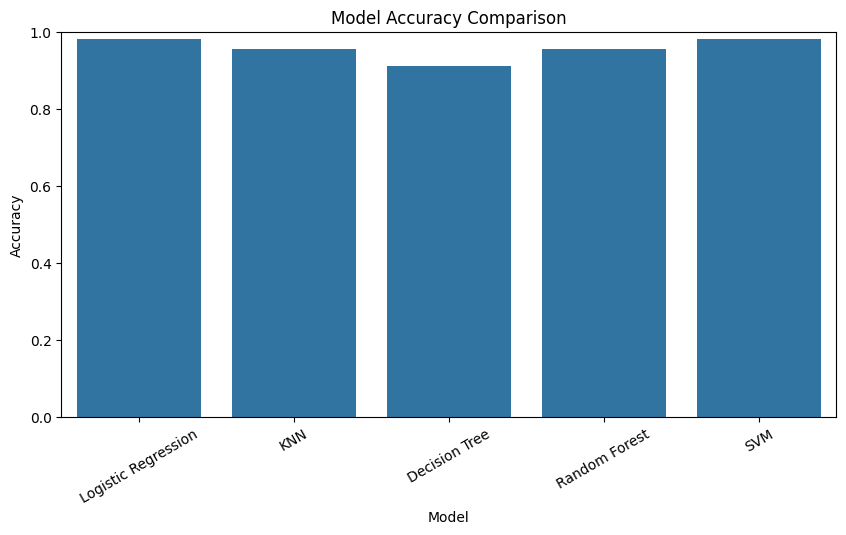

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

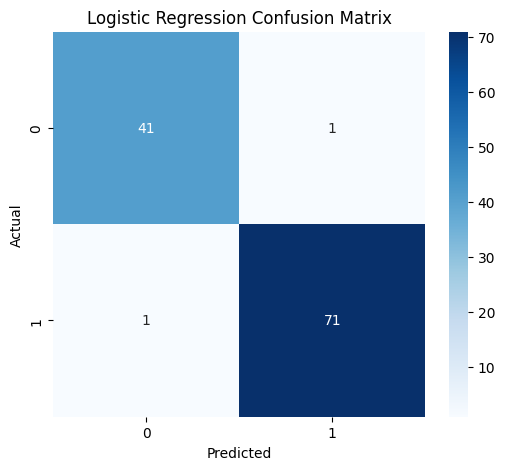

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=data.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


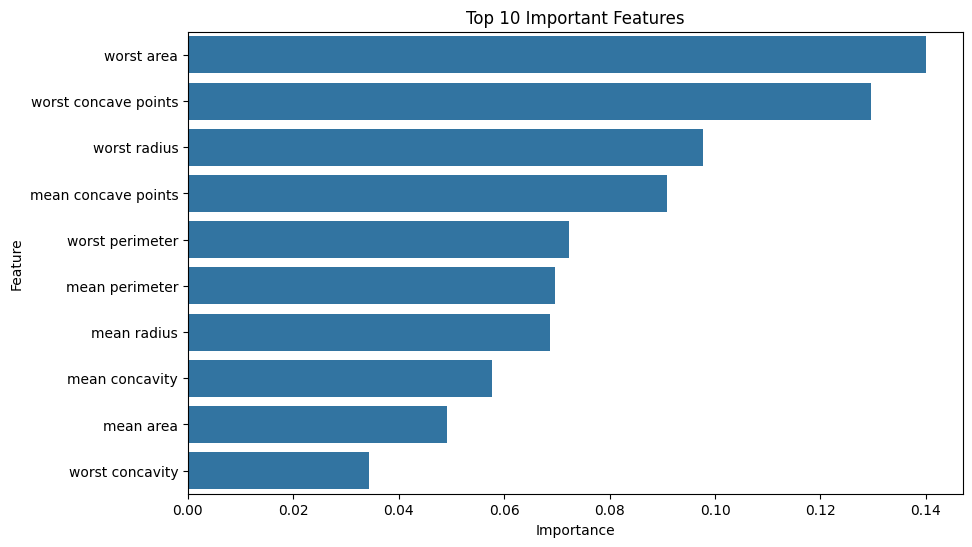

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(
    score_func=f_classif,
    k=10
)

X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_selected = selector.transform(
    X_test_scaled
)

print("Original number of features:", X_train.shape[1])
print("Selected number of features:", X_train_selected.shape[1])

Original number of features: 30
Selected number of features: 10


In [ ]:
selected_features = X.columns[
    selector.get_support()
]

print("Selected features:")
print(selected_features.tolist())

Selected features:
['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points']


In [ ]:
logistic_selected = LogisticRegression(
    max_iter=5000
)

logistic_selected.fit(
    X_train_selected,
    y_train
)

y_pred_selected = logistic_selected.predict(
    X_test_selected
)

print(
    "Accuracy after feature reduction:",
    accuracy_score(y_test, y_pred_selected)
)

Accuracy after feature reduction: 0.9473684210526315


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train.shape[1])
print("PCA features:", X_train_pca.shape[1])

Original features: 30
PCA features: 2


In [ ]:
print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio: [0.44413492 0.18944618]
Total explained variance: 0.6335811006772492


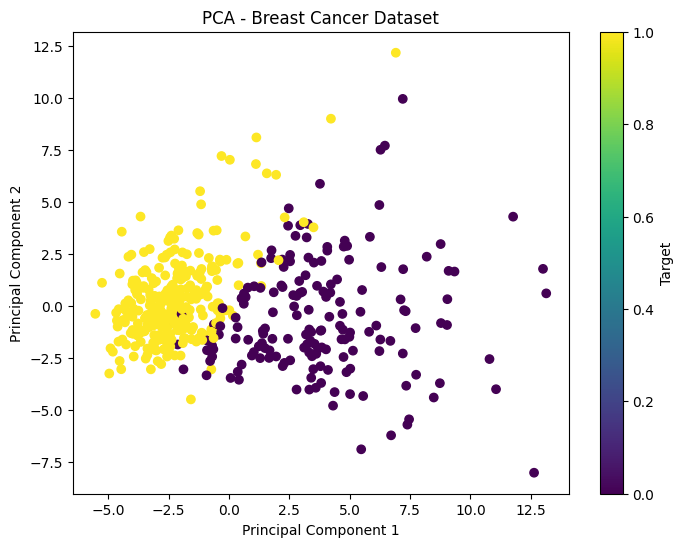

In [ ]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Breast Cancer Dataset")

plt.colorbar(scatter, label="Target")

plt.show()

In [ ]:
pca_model = LogisticRegression(
    max_iter=5000
)

pca_model.fit(
    X_train_pca,
    y_train
)

y_pred_pca = pca_model.predict(
    X_test_pca
)

print(
    "PCA Logistic Regression Accuracy:",
    accuracy_score(y_test, y_pred_pca)
)

PCA Logistic Regression Accuracy: 0.9473684210526315


In [ ]:
pca_95 = PCA(
    n_components=0.95
)

X_train_pca95 = pca_95.fit_transform(
    X_train_scaled
)

X_test_pca95 = pca_95.transform(
    X_test_scaled
)

print(
    "Original features:",
    X_train.shape[1]
)

print(
    "Features after PCA:",
    X_train_pca95.shape[1]
)

print(
    "Explained variance:",
    pca_95.explained_variance_ratio_.sum()
)

Original features: 30
Features after PCA: 10
Explained variance: 0.9526768937417546


In [ ]:
pca95_model = LogisticRegression(
    max_iter=5000
)

pca95_model.fit(
    X_train_pca95,
    y_train
)

y_pred_pca95 = pca95_model.predict(
    X_test_pca95
)

print(
    "PCA 95% Accuracy:",
    accuracy_score(y_test, y_pred_pca95)
)

PCA 95% Accuracy: 0.9736842105263158


In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_train_scaled
)

print("DBSCAN labels:")
print(np.unique(dbscan_labels))

DBSCAN labels:
[-1  0  1  2]


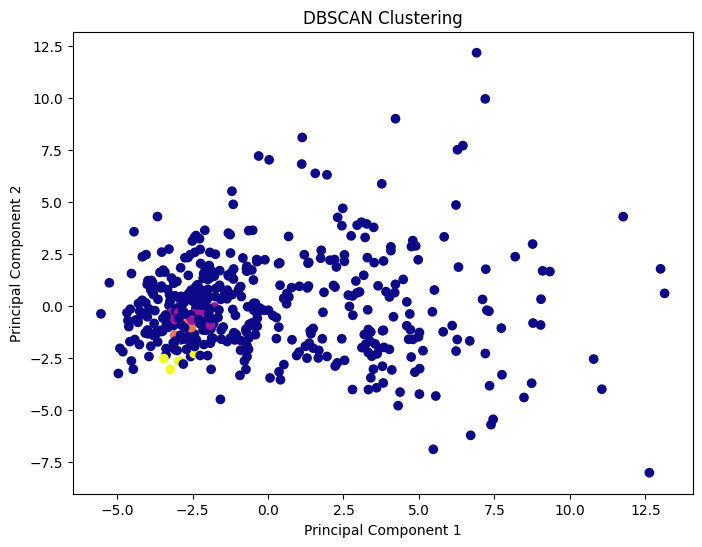

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=dbscan_labels,
    cmap="plasma"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering")

plt.show()

In [ ]:
unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

for label, count in zip(unique_labels, counts):
    print("Cluster", label, ":", count)

Cluster -1 : 433
Cluster 0 : 13
Cluster 1 : 4
Cluster 2 : 5


In [ ]:
final_results = pd.DataFrame({
    "Method": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Logistic Regression + Feature Selection",
        "Logistic Regression + PCA (2)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_forest),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_selected),
        accuracy_score(y_test, y_pred_pca)
    ]
})

final_results

,Method,Accuracy
0,Logistic Regression,0.982456
1,KNN,0.956140
2,Decision Tree,0.912281
3,Random Forest,0.956140
4,SVM,0.982456
5,Logistic Regression + Feature Selection,0.947368
6,Logistic Regression + PCA (2),0.947368


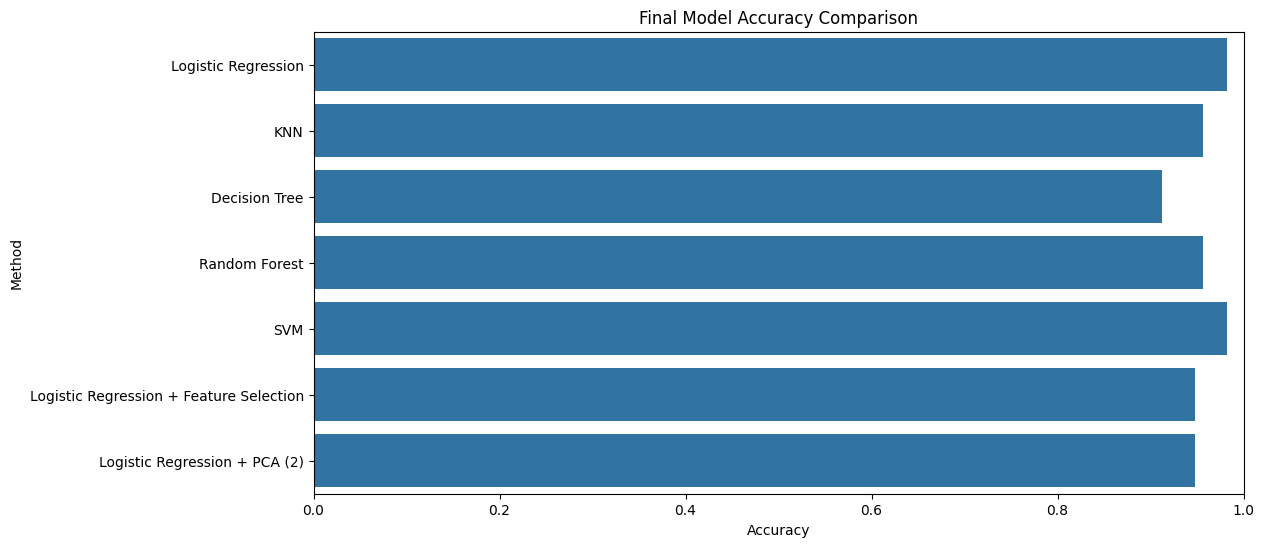

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x="Accuracy",
    y="Method",
    data=final_results
)

plt.xlim(0, 1)
plt.title("Final Model Accuracy Comparison")
plt.show()

In [ ]:
best_model = final_results.loc[
    final_results["Accuracy"].idxmax()
]

print("Best Method:", best_model["Method"])
print("Accuracy:", best_model["Accuracy"])

Best Method: Logistic Regression
Accuracy: 0.9824561403508771


In [ ]:
metric_results = []

for name, predictions in models.items():

    metric_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

metric_df = pd.DataFrame(metric_results)

metric_df.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
4,SVM,0.982456,0.986111,0.986111,0.986111
1,KNN,0.956140,0.958904,0.972222,0.965517
3,Random Forest,0.956140,0.958904,0.972222,0.965517
2,Decision Tree,0.912281,0.955882,0.902778,0.928571


# Conclusion

In this project, the Breast Cancer dataset from Scikit-learn
was analyzed and used for supervised machine learning.

The complete machine learning workflow included:

1. Data loading
2. Data understanding
3. Exploratory Data Analysis
4. Missing-value checking
5. Duplicate checking
6. Feature-target separation
7. Train-test splitting
8. Feature scaling
9. Model training
10. Model evaluation
11. Feature selection
12. PCA dimensionality reduction
13. DBSCAN clustering
14. Model comparison

The supervised learning models used were:

- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- Support Vector Machine

Feature selection reduced the number of original features
while retaining the most useful features.

PCA transformed the original features into a smaller number
of new principal components.

DBSCAN was also demonstrated as an unsupervised learning
method for discovering clusters.

The final model should be selected by considering accuracy,
precision, recall, and F1-score rather than accuracy alone.
For a medical classification problem, recall is particularly
important because false-negative predictions can be serious.